In [1]:
# =============================================================================
# PROYECTO DE INVESTIGACIÓN
# =============================================================================
#
# Curso:
# Métodos de Investigación e Integridad Científica en IA
#
# Proyecto:
# Predicción de la Clasificación de Riesgo de las Cajas Municipales del Perú
# mediante Machine Learning Supervisado
#
# Autor:
# Paul Cusi
#
# Dataset:
# bd3_BALANCEADA.xlsx
#
# Variable Objetivo:
# CALIFICACIÓN
#
# Modelos:
# 2. Logistic Regression
# 3. Decision Tree
# 4. Random Forest
#
# =============================================================================

In [2]:
# =============================================================================
# INSTALACIÓN DE LIBRERÍAS
# =============================================================================

!pip -q install mlflow openpyxl joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [3]:
# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

import os
import random
import time
import json
import warnings

from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
    matthews_corrcoef
)

import joblib

import mlflow

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [4]:
# =============================================================================
# CONFIGURACIÓN DEL EXPERIMENTO
# =============================================================================

SEED = 42

TEST_SIZE = 0.30

CV_FOLDS = 5

TARGET = "CALIFICACIÓN"

RANDOM_SEEDS = [13,21,42,87,100]

EXPERIMENT_NAME = "Prediccion_Riesgo_Cajas"

np.random.seed(SEED)

random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

print("Semilla principal:",SEED)

Semilla principal: 42


In [5]:
# =============================================================================
# REPRODUCIBILIDAD
# =============================================================================

def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"]=str(seed)

set_seed(SEED)

print("Reproducibilidad configurada.")

Reproducibilidad configurada.


In [6]:
# =============================================================================
# GOOGLE DRIVE
# =============================================================================

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# =============================================================================
# ESTRUCTURA DEL PROYECTO
# =============================================================================

PROJECT_DIR="/content/drive/MyDrive/Doctorado_Riesgo"

DATA_DIR=f"{PROJECT_DIR}/data"

MODEL_DIR=f"{PROJECT_DIR}/models"

OUTPUT_DIR=f"{PROJECT_DIR}/outputs"

FIGURE_DIR=f"{PROJECT_DIR}/figures"

REPORT_DIR=f"{PROJECT_DIR}/reports"

MLFLOW_DIR=f"{PROJECT_DIR}/mlruns"

folders=[

PROJECT_DIR,

DATA_DIR,

MODEL_DIR,

OUTPUT_DIR,

FIGURE_DIR,

REPORT_DIR,

MLFLOW_DIR

]

for folder in folders:

    Path(folder).mkdir(parents=True,exist_ok=True)

print("Proyecto creado correctamente.")

Proyecto creado correctamente.


In [8]:
# =============================================================================
# CARGA DEL DATASET
# =============================================================================

FILE_NAME="bd3 BALANCEADA.xlsx"

DATA_PATH=f"{DATA_DIR}/{FILE_NAME}"

raw_df=pd.read_excel(DATA_PATH)

print(raw_df.shape)

raw_df.head()

(19, 229)


,INDICADORES,CASO 1,CASO 2,CASO 3,CASO 4,CASO 5,CASO 6,CASO 7,CASO 8,CASO 9,...,CASO 241,CASO 242,CASO 243,CASO 244,CASO 245,CASO 246,CASO 247,CASO 248,CASO 249,CASO 250
0,Ratio de Capital Global,14.65,15.4,13.13,14.69,15.18,16.87,16.18,15.05,13.6,...,14.35,14.35,14.36,14.06,13.72,14.11,14.17,14,14.17,14.13
1,Pasivo Total / Capital Social y Reservas ( Nº ...,9,6.18,5.85,7.94,6.65,5.38,5.17,8.95,11.1,...,7.87,7.87,7.84,7.82,7.8,7.54,7.54,7.53,7.29,7.37
2,Créditos Atrasados (criterio SBS)** / Créditos...,4.43,4.51,17.45,3.11,7.3,7.3,14.53,6.67,4.6,...,10.8,10.8,11.1,11.52,12.16,12.28,12.94,13.49,13.94,14.53
3,Créditos Atrasados con más de 90 días de atras...,3.222305,3.76017,15.199861,2.736316,6.563604,6.248409,11.92037,5.196822,3.502459,...,10.85,10.85,11.15,11.57,12.21,12.33,12.78,10.928766,11.622336,11.836015
4,Créditos Atrasados MN (criterio SBS)** / Crédi...,4.25,4.37,16.84,3.08,7.27,7.16,14.39,5.32,4.63,...,3.43,3.43,3.53,3.6,4.54,4.45,38.86,13.53,13.99,14.58


In [9]:
# =============================================================================
# TRANSFORMACIÓN DEL DATASET
# =============================================================================

# Transponer el dataset para que cada fila represente un caso
df = raw_df.set_index("INDICADORES").T

# El nombre del índice serán los casos
df.index.name = "CASO"

# Reiniciar índice
df.reset_index(inplace=True)

print("="*60)
print("DIMENSIONES DEL DATASET")
print("="*60)

print(df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

DIMENSIONES DEL DATASET
(228, 20)

Primeras filas:


INDICADORES,CASO,Ratio de Capital Global,Pasivo Total / Capital Social y Reservas ( Nº de veces ),Créditos Atrasados (criterio SBS)** / Créditos Directos,Créditos Atrasados con más de 90 días de atraso / Créditos Directos,Créditos Atrasados MN (criterio SBS)** / Créditos Directos MN,Créditos Atrasados ME (criterio SBS)** / Créditos Directos ME,Provisiones / Créditos Atrasados (%),Gastos de Administración Anualizados/ Créditos Directos e Indirectos Promedio (%),Gastos de Operación Anualizados / Margen Financiero Total Anualizado (%),Ingresos Financieros Anualizados / Activo Productivo Promedio (%),Créditos Directos / Empleados (Miles S/),Créditos Directos / Número de Oficinas (Miles S/),Depósitos/ Créditos Directos (%),Utilidad Neta Anualizada sobre Patrimonio Promedio (%),Utilidad Neta Anualizada sobre Activo Promedio (%),Ratio de Liquidez en M.N. (%) (promedio del mes),Ratio de Liquidez en M.E. (%) (promedio del mes),Posición Global en M.E. / Patrimonio Efectivo ( %),CALIFICACIÓN
0,CASO 1,14.65,9,4.43,3.222305,4.25,10.24,183.77,9.313771,59.320019,18.781438,1105.361913,28211.850649,97.9,19.321813,2.316003,22.92,82.05,-1.29431,B
1,CASO 2,15.4,6.18,4.51,3.76017,4.37,9.03,152.03,6.896967,59.466795,17.195555,1232.747776,23568.963439,91.55,16.728204,2.608771,17.07,73.72,-0.007006,B
2,CASO 3,13.13,5.85,17.45,15.199861,16.84,47.17,97.64,16.043297,83.972435,22.22527,524.175103,10685.107872,116.73,-16.438221,-2.159745,35.16,82.12,-0.181113,D
3,CASO 4,14.69,7.94,3.11,2.736316,3.08,6.35,157.11,10.2888,62.509191,20.277577,1156.803839,22613.979476,86.56,21.643272,3.083731,30.61,101.52,0.137482,B
4,CASO 5,15.18,6.65,7.3,6.563604,7.27,14.13,134.83,11.96599,69.217528,19.856341,862.890773,18319.834879,95.68,12.01085,1.960212,32.75,96.96,2.126936,C



Últimas filas:


INDICADORES,CASO,Ratio de Capital Global,Pasivo Total / Capital Social y Reservas ( Nº de veces ),Créditos Atrasados (criterio SBS)** / Créditos Directos,Créditos Atrasados con más de 90 días de atraso / Créditos Directos,Créditos Atrasados MN (criterio SBS)** / Créditos Directos MN,Créditos Atrasados ME (criterio SBS)** / Créditos Directos ME,Provisiones / Créditos Atrasados (%),Gastos de Administración Anualizados/ Créditos Directos e Indirectos Promedio (%),Gastos de Operación Anualizados / Margen Financiero Total Anualizado (%),Ingresos Financieros Anualizados / Activo Productivo Promedio (%),Créditos Directos / Empleados (Miles S/),Créditos Directos / Número de Oficinas (Miles S/),Depósitos/ Créditos Directos (%),Utilidad Neta Anualizada sobre Patrimonio Promedio (%),Utilidad Neta Anualizada sobre Activo Promedio (%),Ratio de Liquidez en M.N. (%) (promedio del mes),Ratio de Liquidez en M.E. (%) (promedio del mes),Posición Global en M.E. / Patrimonio Efectivo ( %),CALIFICACIÓN
223,CASO 246,14.11,7.54,12.28,12.33,4.45,120.59,17.32,13.56906,81.35055,24.045045,645.857872,13055.55556,104.06,0.788944,0.105178,31.67,111.27,-0.625189,D
224,CASO 247,14.17,7.54,12.94,12.78,38.86,117.17,17.79,13.804413,81.766614,24.202895,647.317054,12946.341079,104.78,1.260415,0.169498,33.05,109.07,0.338892,D
225,CASO 248,14,7.53,13.49,10.928766,13.53,5.32,113.02,14.029131,81.741006,24.381642,655.514428,13110.288566,103.59,1.595824,0.216377,35.04,113.22,0.553126,D
226,CASO 249,14.17,7.29,13.94,11.622336,13.99,5.49,111.19,14.23235,83.067167,24.343006,604.182259,13119.386193,100.16,1.215453,0.166375,32.74,111.58,-0.283928,D
227,CASO 250,14.13,7.37,14.53,11.836015,14.58,5.66,107.23,14.349923,83.079276,24.529613,605.855371,13372.093545,99.42,0.662339,0.091397,30.06,108.94,-0.258242,D


In [10]:
# =============================================================================
# VERIFICAR COLUMNAS
# =============================================================================

print(df.columns.tolist())

['CASO', 'Ratio de Capital Global', 'Pasivo Total / Capital Social y Reservas ( Nº de veces )', 'Créditos Atrasados (criterio SBS)** / Créditos Directos', 'Créditos Atrasados con más de 90 días de atraso / Créditos Directos', 'Créditos Atrasados MN (criterio SBS)** / Créditos Directos MN', 'Créditos Atrasados ME (criterio SBS)** / Créditos Directos ME', 'Provisiones / Créditos Atrasados (%)', 'Gastos de Administración Anualizados/ Créditos Directos e Indirectos Promedio (%)', 'Gastos de Operación Anualizados / Margen Financiero Total Anualizado (%)', 'Ingresos Financieros Anualizados / Activo Productivo Promedio (%)', 'Créditos Directos / Empleados (Miles S/)', 'Créditos Directos / Número de Oficinas (Miles S/)', 'Depósitos/ Créditos Directos (%)', 'Utilidad Neta Anualizada sobre Patrimonio Promedio (%)', 'Utilidad Neta Anualizada sobre Activo Promedio (%)', 'Ratio de Liquidez en M.N. (%) (promedio del mes)', 'Ratio de Liquidez en M.E. (%) (promedio del mes)', 'Posición Global en M.E. 

In [11]:
# =============================================================================
# INFORMACIÓN GENERAL
# =============================================================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 20 columns):
 #   Column                                                                             Non-Null Count  Dtype 
---  ------                                                                             --------------  ----- 
 0   CASO                                                                               228 non-null    object
 1   Ratio de Capital Global                                                            228 non-null    object
 2   Pasivo Total / Capital Social y Reservas ( Nº de veces )                           228 non-null    object
 3   Créditos Atrasados (criterio SBS)** / Créditos Directos                            228 non-null    object
 4   Créditos Atrasados con más de 90 días de atraso / Créditos Directos                228 non-null    object
 5   Créditos Atrasados MN (criterio SBS)** / Créditos Directos MN                      228 non-null    object
 6   Cr

In [13]:
# =============================================================================
# VALORES FALTANTES
# =============================================================================

nulls = df.isnull().sum()

display(nulls[nulls > 0])

print("\nTotal de valores nulos:", nulls.sum())

,0
INDICADORES,



Total de valores nulos: 0


CALIFICACIÓN
B    110
C     69
D     49
Name: count, dtype: int64


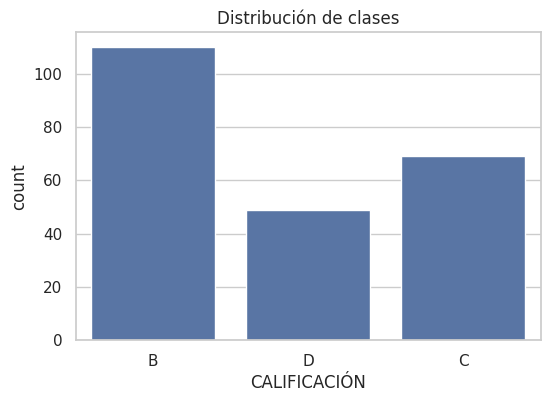

In [14]:
# =============================================================================
# DISTRIBUCIÓN DE CLASES
# =============================================================================

print(df["CALIFICACIÓN"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="CALIFICACIÓN")

plt.title("Distribución de clases")

plt.show()

In [15]:
# =============================================================================
# ESTADÍSTICOS DESCRIPTIVOS
# =============================================================================

print("="*80)
print("ESTADÍSTICOS DESCRIPTIVOS")
print("="*80)

# Excluir columnas no numéricas
numeric_df = df.drop(columns=["CASO", "CALIFICACIÓN"])

display(numeric_df.describe().T)

print("\nNúmero de variables numéricas:", numeric_df.shape[1])
print("Número de observaciones:", numeric_df.shape[0])

ESTADÍSTICOS DESCRIPTIVOS


,count,unique,top,freq
INDICADORES,,,,
Ratio de Capital Global,228.0,195.0,14.170000,5.0
Pasivo Total / Capital Social y Reservas ( Nº de veces ),228.0,202.0,7.540000,3.0
Créditos Atrasados (criterio SBS)** / Créditos Directos,228.0,212.0,7.300000,3.0
Créditos Atrasados con más de 90 días de atraso / Créditos Directos,228.0,227.0,10.850000,2.0
Créditos Atrasados MN (criterio SBS)** / Créditos Directos MN,228.0,200.0,6.560000,4.0
Créditos Atrasados ME (criterio SBS)** / Créditos Directos ME,228.0,220.0,100.000000,3.0
Provisiones / Créditos Atrasados (%),228.0,223.0,125.580000,2.0
Gastos de Administración Anualizados/ Créditos Directos e Indirectos Promedio (%),228.0,227.0,12.630438,2.0
Gastos de Operación Anualizados / Margen Financiero Total Anualizado (%),228.0,227.0,79.267397,2.0



Número de variables numéricas: 18
Número de observaciones: 228


,count
CALIFICACIÓN,
B,110
C,69
D,49


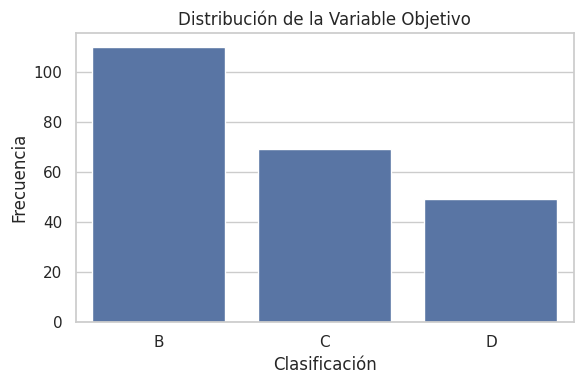

In [16]:
# =============================================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# =============================================================================

class_counts = df["CALIFICACIÓN"].value_counts().sort_index()

display(class_counts)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="CALIFICACIÓN",
    order=sorted(df["CALIFICACIÓN"].unique())
)

plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Clasificación")
plt.ylabel("Frecuencia")

plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/class_distribution.png", dpi=300)

plt.show()

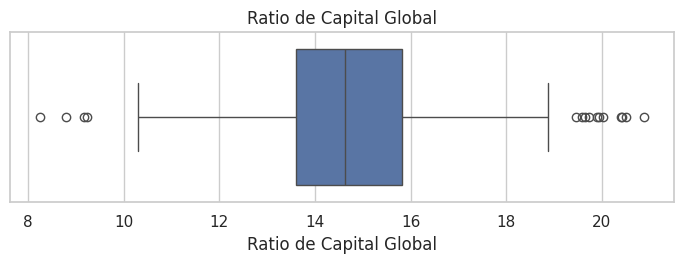

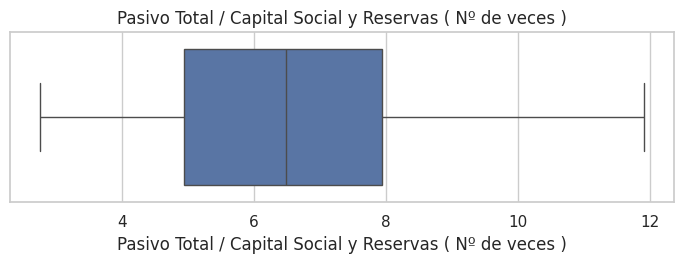

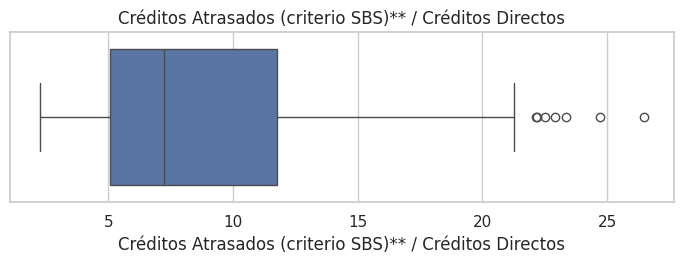

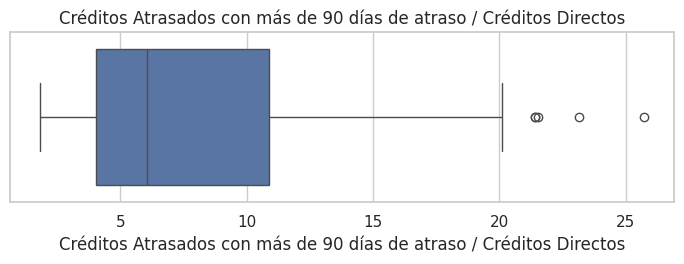

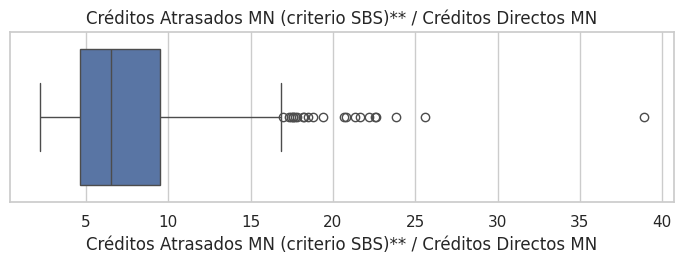

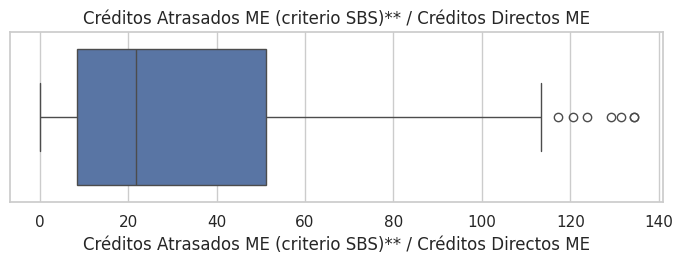

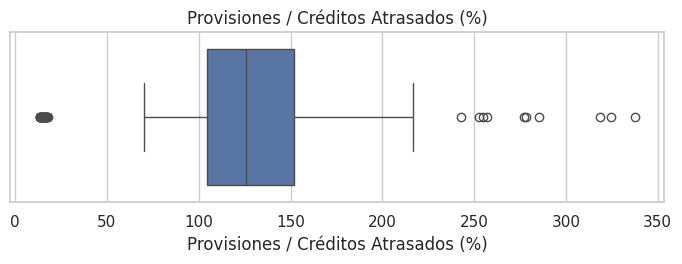

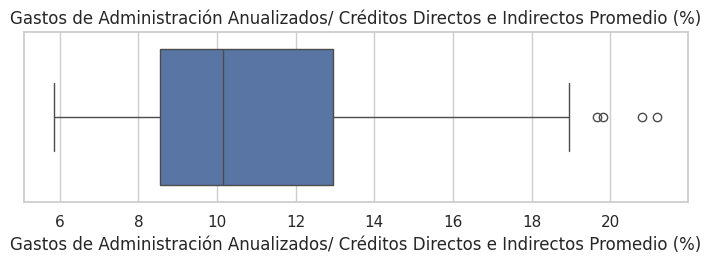

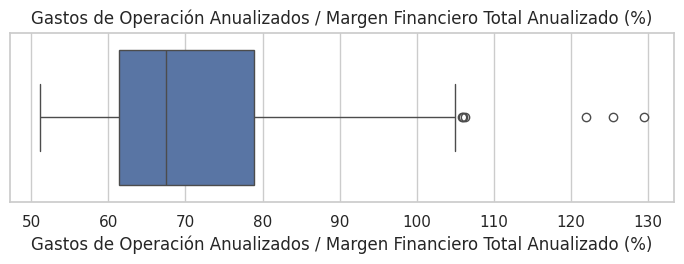

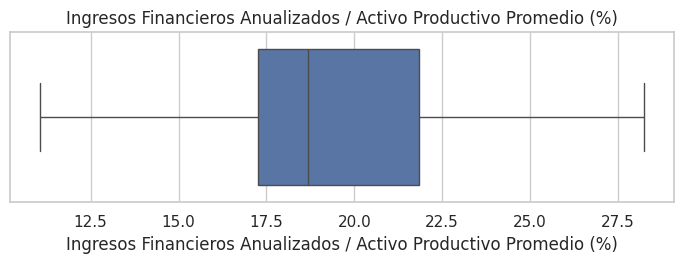

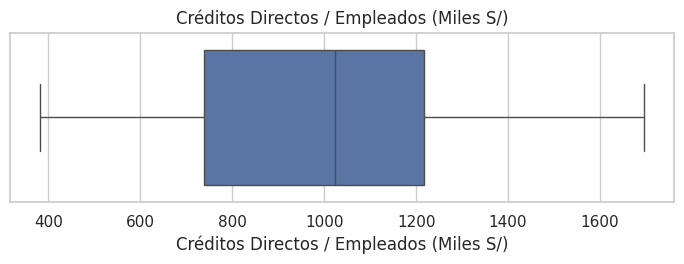

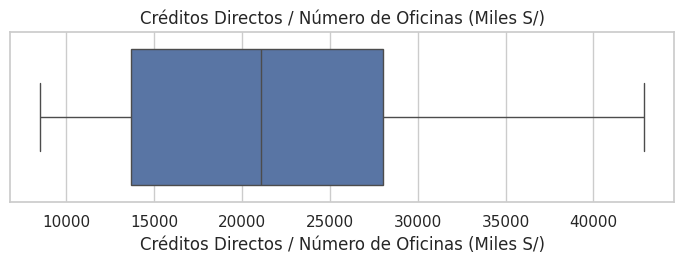

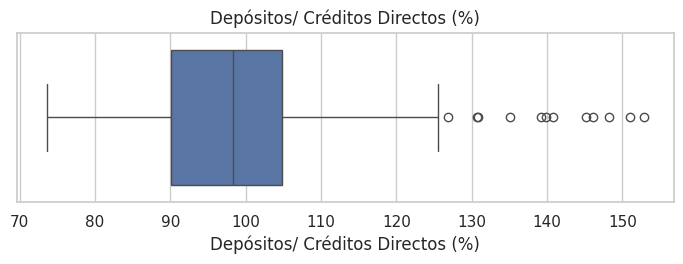

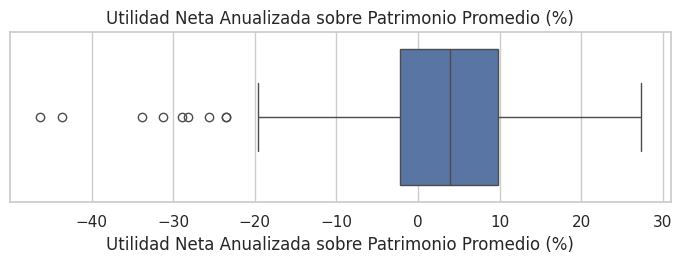

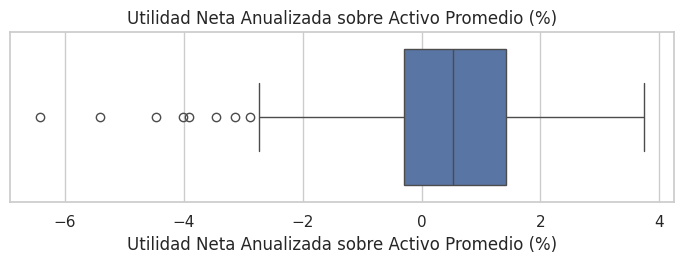

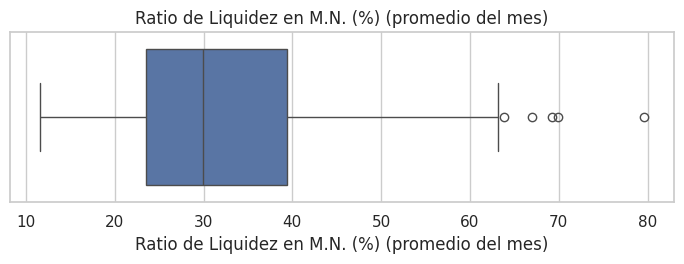

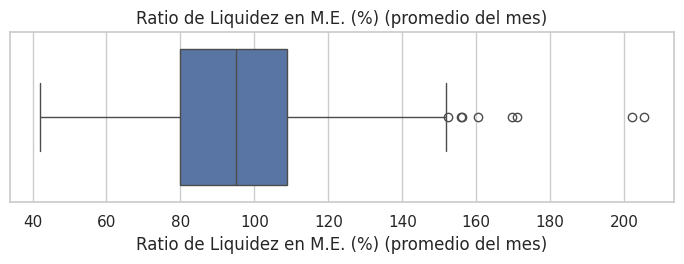

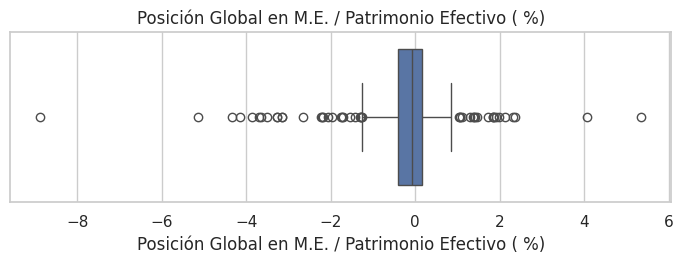

In [17]:
# =============================================================================
# BOXPLOTS
# =============================================================================

for column in numeric_df.columns:

    plt.figure(figsize=(7,2.8))

    sns.boxplot(
        x=numeric_df[column]
    )

    plt.title(column)

    plt.tight_layout()

    plt.show()

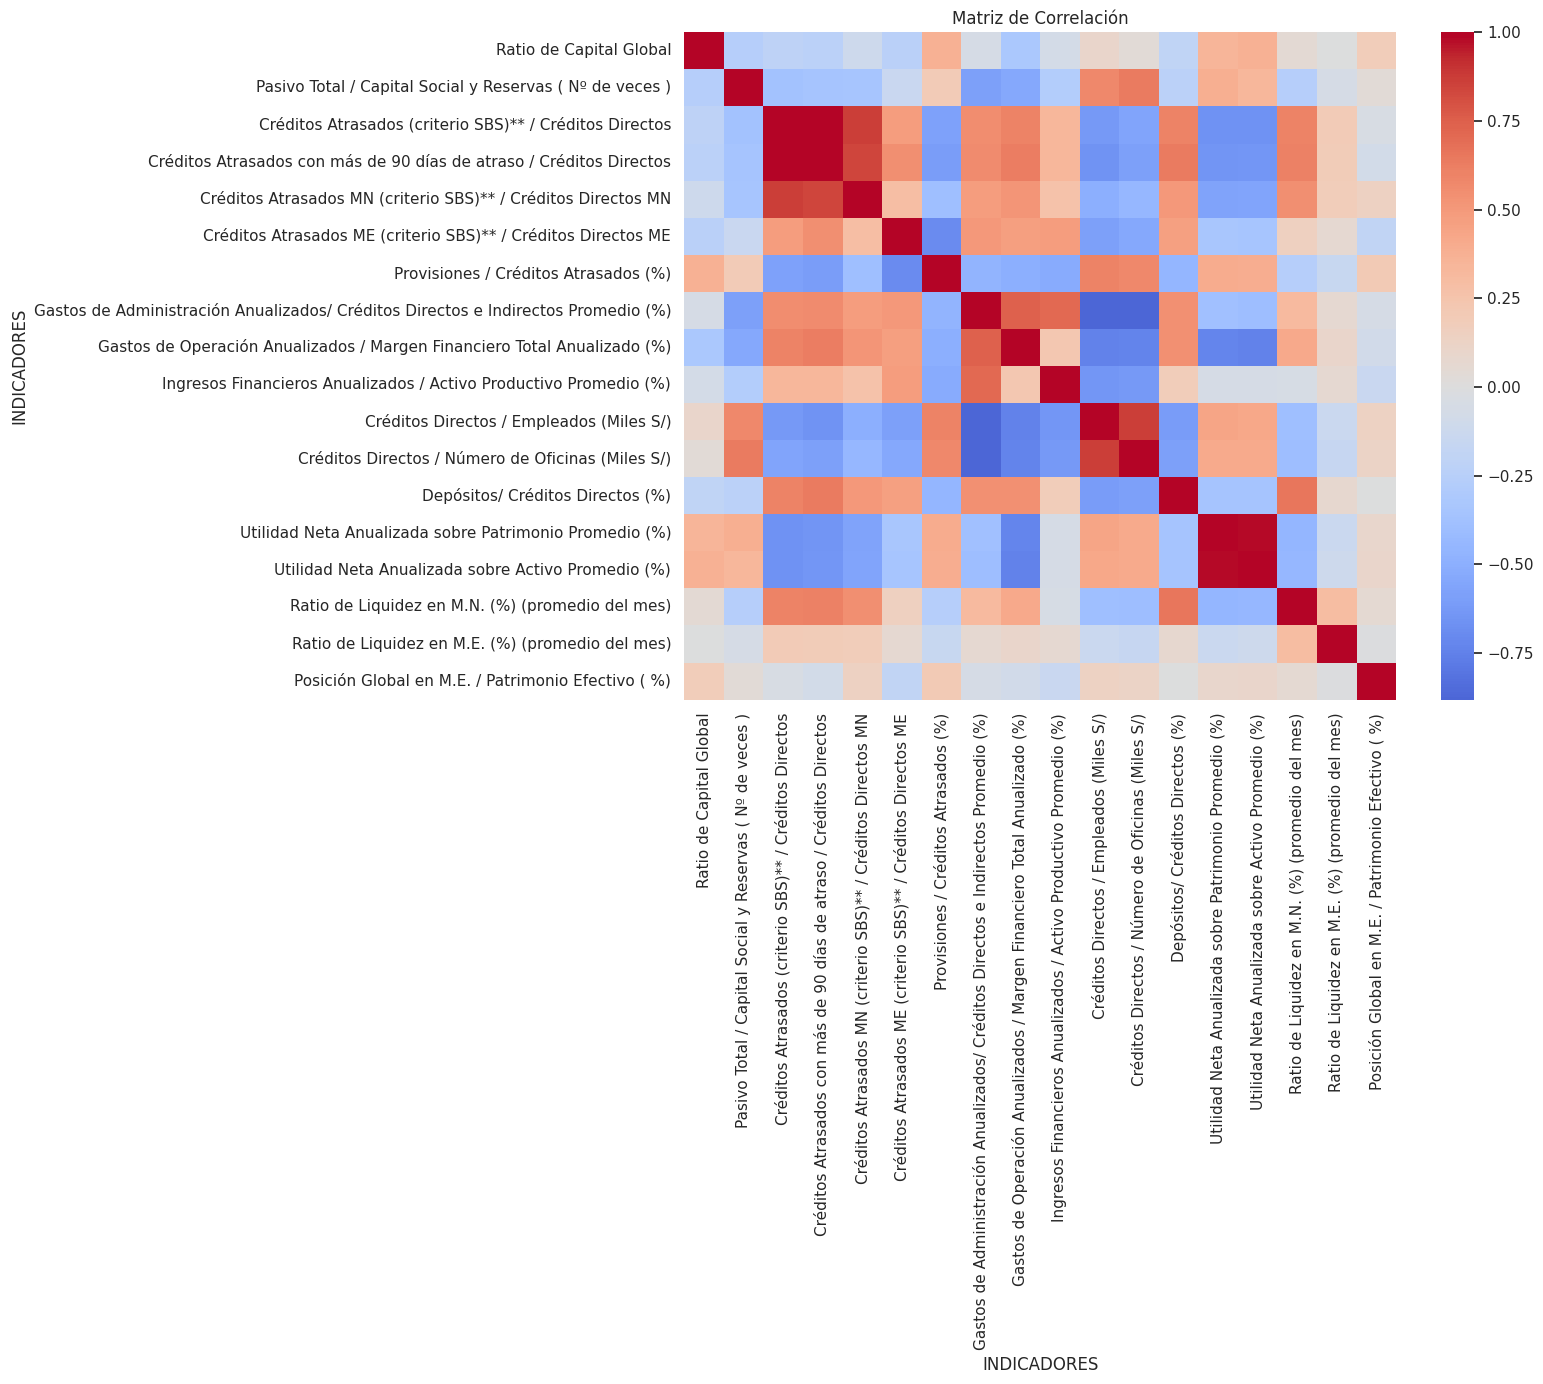

In [18]:
# =============================================================================
# MATRIZ DE CORRELACIÓN
# =============================================================================

corr = numeric_df.corr()

plt.figure(figsize=(16,14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlación")

plt.tight_layout()

plt.savefig(f"{FIGURE_DIR}/correlation_matrix.png", dpi=300)

plt.show()

In [19]:
# =============================================================================
# VARIABLES MÁS CORRELACIONADAS
# =============================================================================

corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

display(high_corr.head(20))

INDICADORES                                                                        INDICADORES                                                             
Créditos Atrasados (criterio SBS)** / Créditos Directos                            Créditos Atrasados con más de 90 días de atraso / Créditos Directos         0.987182
Utilidad Neta Anualizada sobre Patrimonio Promedio (%)                             Utilidad Neta Anualizada sobre Activo Promedio (%)                          0.985066
Gastos de Administración Anualizados/ Créditos Directos e Indirectos Promedio (%)  Créditos Directos / Empleados (Miles S/)                                    0.881321
                                                                                   Créditos Directos / Número de Oficinas (Miles S/)                           0.880674
Créditos Atrasados (criterio SBS)** / Créditos Directos                            Créditos Atrasados MN (criterio SBS)** / Créditos Directos MN               0.874128
Créditos Directos / Empleados (Miles S/)                                           Créditos Directos / Número de Oficinas (Miles S/)                           0.872784
Créditos Atrasados con más de 90 días de atraso / Créditos Directos                Créditos Atrasados MN (criterio SBS)** / Créditos Directos MN               0.844045
Gastos de Administración Anualizados/ Créditos Directos e Indirectos Promedio (%)  Gastos de Operación Anualizados / Margen Financiero Total Anualizado (%)    0.744936
Gastos de Operación Anualizados / Margen Financiero Total Anualizado (%)           Utilidad Neta Anualizada sobre Activo Promedio (%)                          0.744482
                                                                                   Créditos Directos / Empleados (Miles S/)                                    0.742339
                                                                                   Créditos Directos / Número de Oficinas (Miles S/)                           0.737211
                                                                                   Utilidad Neta Anualizada sobre Patrimonio Promedio (%)                      0.733906
Gastos de Administración Anualizados/ Créditos Directos e Indirectos Promedio (%)  Ingresos Financieros Anualizados / Activo Productivo Promedio (%)           0.707730
Créditos Atrasados ME (criterio SBS)** / Créditos Directos ME                      Provisiones / Créditos Atrasados (%)                                        0.692958
Créditos Atrasados (criterio SBS)** / Créditos Directos                            Utilidad Neta Anualizada sobre Patrimonio Promedio (%)                      0.662602
                                                                                   Utilidad Neta Anualizada sobre Activo Promedio (%)                          0.661057
Depósitos/ Créditos Directos (%)                                                   Ratio de Liquidez en M.N. (%) (promedio del mes)                            0.657711
Créditos Atrasados con más de 90 días de atraso / Créditos Directos                Créditos Directos / Empleados (Miles S/)                                    0.654199
                                                                                   Utilidad Neta Anualizada sobre Patrimonio Promedio (%)                      0.648217
                                                                                   Utilidad Neta Anualizada sobre Activo Promedio (%)                          0.645871
dtype: float64

In [20]:
# =============================================================================
# PREPARACIÓN DE VARIABLES
# =============================================================================

from sklearn.preprocessing import LabelEncoder

# Variables predictoras
X = df.drop(columns=["CASO", "CALIFICACIÓN"])

# Variable objetivo
y = df["CALIFICACIÓN"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nClases originales:")
print(y.value_counts())

Dimensión de X: (228, 18)
Dimensión de y: (228,)

Clases originales:
CALIFICACIÓN
B    110
C     69
D     49
Name: count, dtype: int64


In [21]:
# =============================================================================
# LABEL ENCODER
# =============================================================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Clases originales:")
print(encoder.classes_)

print("\nCodificación:")

for clase, codigo in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(f"{clase} --> {codigo}")

Clases originales:
['B' 'C' 'D']

Codificación:
B --> 0
C --> 1
D --> 2


In [22]:
# =============================================================================
# TRAIN TEST SPLIT
# =============================================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (159, 18)
Test : (69, 18)


In [23]:
# =============================================================================
# STANDARD SCALER
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Escalamiento completado.")

Escalamiento completado.


In [24]:
# =============================================================================
# FUNCIÓN DE EVALUACIÓN
# =============================================================================

import time
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    kappa = cohen_kappa_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "Modelo": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Kappa": kappa,
        "MCC": mcc,
        "Tiempo (s)": end-start
    })

    print("="*70)
    print(name)
    print("="*70)

    print("\nAccuracy:", accuracy)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))

    return model

In [25]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy = evaluate_model(
    "Dummy",
    dummy,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Dummy

Accuracy: 0.4782608695652174

Classification Report

              precision    recall  f1-score   support

           0       0.48      1.00      0.65        33
           1       0.00      0.00      0.00        21
           2       0.00      0.00      0.00        15

    accuracy                           0.48        69
   macro avg       0.16      0.33      0.22        69
weighted avg       0.23      0.48      0.31        69


Confusion Matrix

[[33  0  0]
 [21  0  0]
 [15  0  0]]


In [26]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic = evaluate_model(
    "Logistic Regression",
    logistic,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Logistic Regression

Accuracy: 0.8985507246376812

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.77      0.95      0.85        21
           2       1.00      0.87      0.93        15

    accuracy                           0.90        69
   macro avg       0.91      0.90      0.90        69
weighted avg       0.91      0.90      0.90        69


Confusion Matrix

[[29  4  0]
 [ 1 20  0]
 [ 0  2 13]]


In [27]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree = evaluate_model(
    "Decision Tree",
    tree,
    X_train,
    X_test,
    y_train,
    y_test
)

Decision Tree

Accuracy: 0.855072463768116

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.88      0.87        33
           1       0.88      0.71      0.79        21
           2       0.83      1.00      0.91        15

    accuracy                           0.86        69
   macro avg       0.86      0.86      0.85        69
weighted avg       0.86      0.86      0.85        69


Confusion Matrix

[[29  2  2]
 [ 5 15  1]
 [ 0  0 15]]


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf = evaluate_model(
    "Random Forest",
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Random Forest

Accuracy: 0.8985507246376812

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.79      0.90      0.84        21
           2       1.00      0.93      0.97        15

    accuracy                           0.90        69
   macro avg       0.91      0.91      0.91        69
weighted avg       0.91      0.90      0.90        69


Confusion Matrix

[[29  4  0]
 [ 2 19  0]
 [ 0  1 14]]


In [29]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(results_df)

,Modelo,Accuracy,Precision,Recall,F1,Kappa,MCC,Tiempo (s)
1,Logistic Regression,0.898551,0.913824,0.898551,0.901186,0.840594,0.845900,0.195325
3,Random Forest,0.898551,0.905739,0.898551,0.900324,0.840278,0.842233,1.420352
2,Decision Tree,0.855072,0.857630,0.855072,0.851920,0.770916,0.774260,0.009784
0,Dummy,0.478261,0.228733,0.478261,0.309463,0.000000,0.000000,0.002155


In [30]:
# =============================================================================
# VALIDACIÓN CRUZADA
# =============================================================================

from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

for name, model in models.items():

    if name == "Logistic Regression":
        scores = cross_val_score(
            model,
            StandardScaler().fit_transform(X),
            y_encoded,
            cv=5,
            scoring="accuracy"
        )
    else:
        scores = cross_val_score(
            model,
            X,
            y_encoded,
            cv=5,
            scoring="accuracy"
        )

    cv_results.append({
        "Modelo": name,
        "Accuracy Promedio": scores.mean(),
        "Desviación": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

display(cv_df)

,Modelo,Accuracy Promedio,Desviación
0,Logistic Regression,0.850821,0.073529
1,Decision Tree,0.784638,0.107223
2,Random Forest,0.898744,0.100151


,Variable,Importancia
6,Provisiones / Créditos Atrasados (%),0.166246
10,Créditos Directos / Empleados (Miles S/),0.137102
3,Créditos Atrasados con más de 90 días de atras...,0.106763
8,Gastos de Operación Anualizados / Margen Finan...,0.094234
2,Créditos Atrasados (criterio SBS)** / Créditos...,0.075688
12,Depósitos/ Créditos Directos (%),0.065651
7,Gastos de Administración Anualizados/ Créditos...,0.059996
5,Créditos Atrasados ME (criterio SBS)** / Crédi...,0.042125
13,Utilidad Neta Anualizada sobre Patrimonio Prom...,0.039837
11,Créditos Directos / Número de Oficinas (Miles S/),0.039331


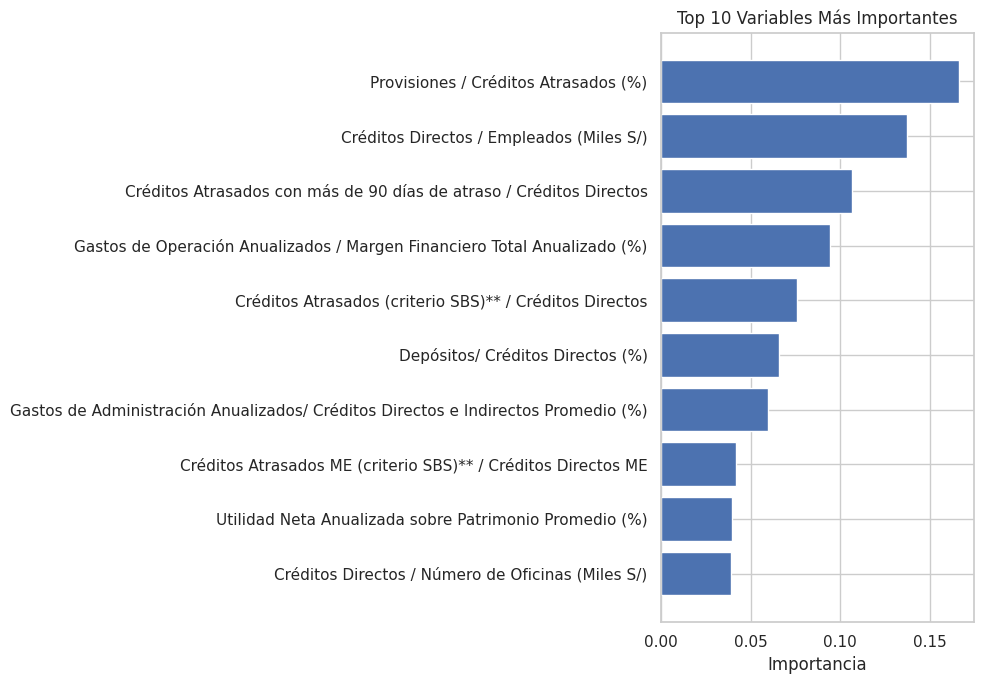

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importancia",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,7))

plt.barh(
    importance["Variable"][:10],
    importance["Importancia"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Variables Más Importantes")

plt.xlabel("Importancia")

plt.tight_layout()

plt.show()

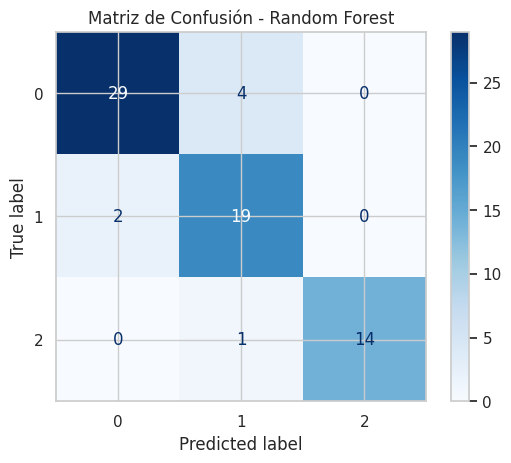

In [32]:
# =============================================================================
# MATRIZ DE CONFUSIÓN - RANDOM FOREST
# =============================================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [33]:
# =============================================================================
# GUARDAR MODELOS Y RESULTADOS
# =============================================================================

import os
import joblib

# Crear estructura del proyecto
folders = [
    "data",
    "models",
    "outputs",
    "figures",
    "reports",
    "mlruns"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✓ Carpetas creadas correctamente.")

# ======================================================
# Guardar modelos
# ======================================================

joblib.dump(rf, "models/random_forest_model.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(encoder, "models/label_encoder.joblib")

print("✓ Modelos guardados.")

# ======================================================
# Guardar resultados
# ======================================================

results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

importance.to_csv(
    "outputs/feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

cv_df.to_csv(
    "outputs/cross_validation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✓ Resultados exportados.")

# ======================================================
# Guardar figuras (si existen)
# ======================================================

print("\nArchivos creados:")
print("- models/random_forest_model.joblib")
print("- models/scaler.joblib")
print("- models/label_encoder.joblib")
print("- outputs/model_comparison.csv")
print("- outputs/feature_importance.csv")
print("- outputs/cross_validation_results.csv")

✓ Carpetas creadas correctamente.
✓ Modelos guardados.
✓ Resultados exportados.

Archivos creados:
- models/random_forest_model.joblib
- models/scaler.joblib
- models/label_encoder.joblib
- outputs/model_comparison.csv
- outputs/feature_importance.csv
- outputs/cross_validation_results.csv


In [34]:
!pip install -q mlflow

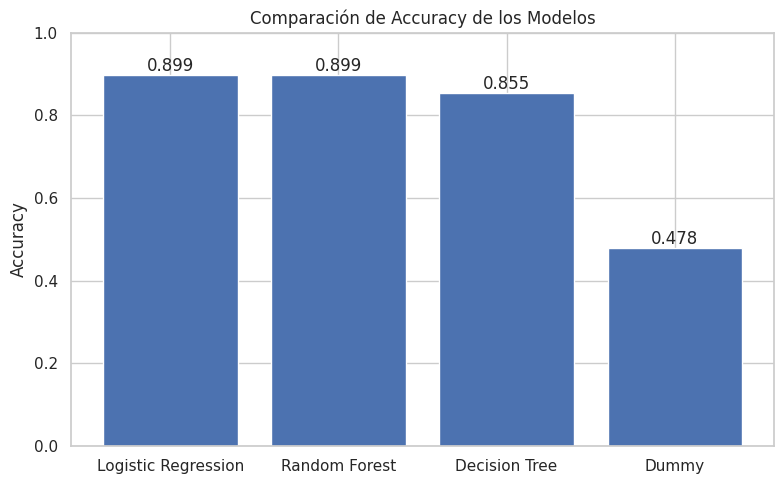

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Modelo"], results_df["Accuracy"])

plt.title("Comparación de Accuracy de los Modelos")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

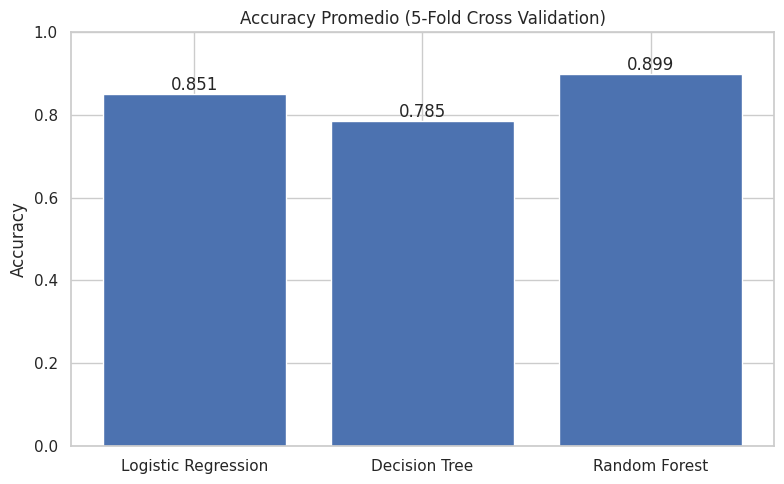

In [36]:
plt.figure(figsize=(8,5))

plt.bar(cv_df["Modelo"], cv_df["Accuracy Promedio"])

plt.title("Accuracy Promedio (5-Fold Cross Validation)")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i,v in enumerate(cv_df["Accuracy Promedio"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [37]:
best = results_df.iloc[0]

print("="*70)
print("CONCLUSIONES")
print("="*70)

print(f"""
El modelo con mejor desempeño fue {best['Modelo']}.

Accuracy : {best['Accuracy']:.4f}
Precision: {best['Precision']:.4f}
Recall   : {best['Recall']:.4f}
F1 Score : {best['F1']:.4f}
Kappa    : {best['Kappa']:.4f}
MCC      : {best['MCC']:.4f}
""")

CONCLUSIONES

El modelo con mejor desempeño fue Logistic Regression.

Accuracy : 0.8986
Precision: 0.9138
Recall   : 0.8986
F1 Score : 0.9012
Kappa    : 0.8406
MCC      : 0.8459



In [38]:
# =============================================================================
# GENERAR DOCUMENTACIÓN DEL PROYECTO
# =============================================================================

import os

os.makedirs("reports", exist_ok=True)

# ======================================================
# README
# ======================================================

readme = """# AI-Based Credit Risk Classification for Peruvian Municipal Savings Banks

## Project Overview

This project develops supervised Machine Learning models to predict the financial risk classification of Peruvian Municipal Savings Banks using financial indicators published by the SBS.

## Dataset

Source:
Superintendencia de Banca, Seguros y AFP (SBS)

Period:
2014–2025

Observations:
228

Predictor Variables:
18 financial indicators

Target:
CALIFICACIÓN

---

## Models

- Dummy Classifier
- Logistic Regression
- Decision Tree
- Random Forest

---

## Test Results

| Model | Accuracy |
|--------|----------|
| Logistic Regression | 89.86% |
| Random Forest | 89.86% |
| Decision Tree | 85.51% |
| Dummy | 47.83% |

---

## Cross Validation

Random Forest achieved the best generalization performance.

---

## Author

Paul Cusi
Master in Artificial Intelligence
Universidad Nacional de Ingeniería
"""

with open("README.md","w",encoding="utf-8") as f:
    f.write(readme)

# ======================================================
# REQUIREMENTS
# ======================================================

requirements = """
numpy
pandas
matplotlib
scikit-learn
mlflow
joblib
openpyxl
"""

with open("requirements.txt","w") as f:
    f.write(requirements)

# ======================================================
# GITIGNORE
# ======================================================

gitignore = """
__pycache__/
.ipynb_checkpoints/
*.pyc
*.log
.DS_Store
Thumbs.db
"""

with open(".gitignore","w") as f:
    f.write(gitignore)

print("README.md creado")
print("requirements.txt creado")
print(".gitignore creado")

README.md creado
requirements.txt creado
.gitignore creado


In [39]:
# =============================================================================
# GENERAR DOCUMENTACIÓN CIENTÍFICA
# =============================================================================

import os

os.makedirs("reports", exist_ok=True)

# ============================================================
# MODEL CARD
# ============================================================

model_card = """
# Model Card

## Model Name

Random Forest Classifier

---

## Purpose

Predict the financial risk classification of Peruvian Municipal Savings Banks using financial indicators published by the SBS.

---

## Dataset

Source:
Superintendencia de Banca, Seguros y AFP (SBS)

Period:
2014-2025

Samples:
228

Predictor Variables:
18

Target:
CALIFICACIÓN

---

## Algorithms Evaluated

- Dummy Classifier
- Logistic Regression
- Decision Tree
- Random Forest

---

## Final Model

Random Forest

---

## Performance

Test Accuracy:
89.86%

Cross Validation Accuracy:
89.87%

---

## Top Important Variables

1. Provisiones / Créditos Atrasados
2. Créditos Directos / Empleados
3. Créditos Atrasados > 90 días
4. Gastos de Operación
5. Créditos Atrasados

---

## Intended Users

Researchers

Financial analysts

Risk management professionals

---

## Limitations

The model was trained only with historical financial indicators.

Predictions should support decision-making, not replace expert judgment.

"""

with open("reports/model_card.md","w",encoding="utf8") as f:
    f.write(model_card)

# ============================================================
# DATASET SHEET
# ============================================================

datasheet = """
# Dataset Sheet

## Dataset Name

Financial Indicators of Peruvian Municipal Savings Banks

---

## Source

Superintendencia de Banca, Seguros y AFP (SBS)

---

## Domain

Financial Risk

---

## Time Period

2014-2025

---

## Number of Samples

228

---

## Number of Variables

18

---

## Target Variable

CALIFICACIÓN

---

## Missing Values

No missing values after preprocessing.

---

## Data Type

Structured tabular data.

---

## Intended Use

Research in Machine Learning and Financial Risk Classification.

"""

with open("reports/datasheet.md","w",encoding="utf8") as f:
    f.write(datasheet)

# ============================================================
# METHODOLOGY
# ============================================================

methodology = """
# Methodology

The project follows a supervised Machine Learning workflow.

## Steps

1. Data collection

2. Data cleaning

3. Exploratory Data Analysis

4. Data preprocessing

5. Label Encoding

6. Train/Test Split

7. Feature Scaling

8. Model Training

    - Dummy Classifier
    - Logistic Regression
    - Decision Tree
    - Random Forest

9. Model Comparison

10. Cross Validation

11. Feature Importance

12. Model Export

"""

with open("reports/methodology.md","w",encoding="utf8") as f:
    f.write(methodology)

# ============================================================
# CONCLUSIONS
# ============================================================

conclusions = """
# Conclusions

The Random Forest classifier achieved the best overall performance.

Main findings

• Test Accuracy: 89.86%

• Cross Validation Accuracy: 89.87%

• The most influential variables were related to loan quality, provisions and operational indicators.

• Random Forest demonstrated better generalization capability than the remaining evaluated models.

Future Work

• Hyperparameter optimization

• XGBoost comparison

• Explainability using SHAP

• External validation with future SBS data

"""

with open("reports/conclusions.md","w",encoding="utf8") as f:
    f.write(conclusions)

print("✓ model_card.md creado")
print("✓ datasheet.md creado")
print("✓ methodology.md creado")
print("✓ conclusions.md creado")

✓ model_card.md creado
✓ datasheet.md creado
✓ methodology.md creado
✓ conclusions.md creado


In [40]:
# =============================================================================
# CREAR LICENSE (MIT)
# =============================================================================

license_text = """MIT License

Copyright (c) 2026 Paul Cusi

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND.
"""

with open("LICENSE", "w", encoding="utf-8") as f:
    f.write(license_text)

print("✓ LICENSE creado")

✓ LICENSE creado


In [41]:
# =============================================================================
# VER ESTRUCTURA DEL PROYECTO
# =============================================================================

import os

for root, dirs, files in os.walk("."):
    level = root.replace(".", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

./
    LICENSE
    requirements.txt
    README.md
    .gitignore
    .config/
        config_sentinel
        .last_update_check.json
        .last_opt_in_prompt.yaml
        gce
        .last_survey_prompt.yaml
        hidden_gcloud_config_universe_descriptor_data_cache_configs.db
        default_configs.db
        active_config
        logs/
            2026.06.04/
                13.32.39.344962.log
                13.32.38.346437.log
                13.32.18.735754.log
                13.31.42.499627.log
                13.32.21.210570.log
                13.32.02.654775.log
        configurations/
            config_default
    models/
        label_encoder.joblib
        random_forest_model.joblib
        scaler.joblib
    data/
    outputs/
        model_comparison.csv
        cross_validation_results.csv
        feature_importance.csv
    mlruns/
    reports/
        methodology.md
        datasheet.md
        model_card.md
        conclusions.md
    drive/
        .shortcut-ta